<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Análisis Exploratorio de Datos (EDA) - Dataset de Diabetes

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Descripción del Problema
Este dataset proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir, basándose en medidas diagnósticas, si un paciente tiene o no diabetes.

#### Este EDA se compartirá para algoritmos basados en árboles
* Árboles de Decisión (Decision Tree)
* Bosques Aleatorios (Random Forest - Conjunto de árboles de decisión)
* Boosting o Árboles de Decisión Secuenciales (XGBoost, AdaBoost, Gradient Boosting)

#### Verificaciones a realizar en este EDA:
* Verificación de valores faltantes
* Verificación de filas duplicadas
* Distribución de la variable objetivo (detección de desbalance de clases)
* Tipos de datos de las características (se necesita codificación si hay categóricas)
* Distribuciones básicas de características (comprensión, no transformación)

#### Verificaciones que NO necesito hacer en este EDA:

* Escalado/Normalización de características
* Transformaciones logarítmicas o polinómicas  
* Tests de normalidad (Shapiro-Wilk, gráficos Q-Q)
* Eliminación de valores atípicos basado en distribución
* Verificaciones de multicolinealidad (VIF)
* Supuestos de linealidad

#### Consideraciones en algoritmos basados en árboles
| **Aspecto** | **Árbol de Decisión** | **Random Forest** | **Boosting** |
|------------|-------------------|-------------------|--------------|
| **Sobreajuste** | Riesgo alto | Riesgo bajo (promediado) | Riesgo medio |
| **Importancia de características** | Árbol único | Promediado entre árboles | Contribución secuencial |
| **Manejo del desbalance** | `class_weight` | `class_weight` | `scale_pos_weight` (XGBoost) |
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Importar Librerías y Cargar Dataset

</div>

In [ ]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns


# Librerías para preprocesamiento y Machine Learning
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Guardar datos
import os

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de visualización
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [26]:
# Cargar los datos
df = pd.read_csv('../data/raw/diabetes.csv', sep=',')
target_column = 'Outcome'
display(df.head())

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("Forma del df:", df.shape)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Columnas del dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Forma del df: (768, 9)


In [27]:
display(df.info())

print(f"\nTodas las variables son numéricas")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


Todas las variables son numéricas


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

* El dataframe tiene 768 filas y 9 variables

* Todas las columnas son numéricas

##### Columnas:

- **Pregnancies (Embarazos)**: La mayoría de las mujeres tienen 0-6 embarazos, pero hay valores atípicos hasta 17. Distribución sesgada a la derecha

- **Glucose (Glucosa)**: Pocos valores atípicos en ambos extremos. Distribución relativamente normal

- **BloodPressure (Presión Arterial)**: Muchos valores atípicos, especialmente valores altos

- **Insulin (Insulina)**: Valores atípicos EXTREMOS llegando a 600-800. La mayoría de valores agrupados bajos. Altamente sesgada a la derecha

- **BMI (Índice de Masa Corporal)**: Algunos valores atípicos altos (60-70). La mayoría de valores entre 25-40. Pocos casos de obesidad extrema

- **SkinThickness (Grosor de la Piel)**: Valores atípicos moderados. Relativamente simétrico

- **DiabetesPedigreeFunction (Función de Pedigrí de Diabetes)**: Muchos valores atípicos pequeños. Concentrados cerca de 0-1

- **Age (Edad)**: Pocos valores atípicos. Distribución uniforme. Rango 21-80 años

- **Outcome (Resultado)**: Binario (0 o 1). 0 -> Sin diabetes y 1 -> Con diabetes
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

# Paso 2 - Analizar Dataset para usar un algoritmo basado en Árbol de Decisiones

#### Preparar y Analizar Datos para Modelos de Árbol de Decisión

Para Árboles de Decisión, **NO** necesito verificar:
- No necesito verificar el test de Normalidad (Shapiro-Wilk, gráficos Q-Q)
- Escalado/Estandarización
- Transformación logarítmica o cuadrática
- Eliminación de valores atípicos
- Verificaciones de multicolinealidad
- Supuestos de linealidad

Para Árboles de Decisión, necesito verificar:
- Valores Faltantes
- Filas duplicadas
- Análisis de Variable Objetivo (Detección de desbalance de clases)
- Análisis de tipos de datos de características (si hay variables categóricas, necesito codificarlas)
- Cardinalidad de características (para características categóricas), alta cardinalidad puede llevar a sobreajuste en Árboles de Decisión
- Selección de métricas - si el dataset está desbalanceado, la precisión no es una buena métrica. Debemos usar precision, recall o F1-score

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Métricas Estadísticas

</div>

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Análisis de Valores Faltantes

</div>

In [29]:
print("="*70)
print("VALORES FALTANTES")
print("="*70)

display(df.isnull().sum())

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Conteo_Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Conteo_Faltantes'] > 0].sort_values('Conteo_Faltantes', ascending=False)

if len(missing_df) > 0:
    print("Columnas con valores faltantes:")
    display(missing_df)
    
    # Visualizar valores faltantes
    plt.figure(figsize=(10, 6))
    missing_df['Porcentaje'].plot(kind='barh', color='coral')
    plt.title('Porcentaje de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
    plt.xlabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ ¡No se encontraron valores faltantes en el dataset!")

VALORES FALTANTES


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✓ ¡No se encontraron valores faltantes en el dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Detectar Duplicados
</div>

In [30]:
# Verificar filas duplicadas
print("="*70)
print("DETECCIÓN DE FILAS DUPLICADAS")
print("="*70)

# Contar total de duplicados
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal de filas duplicadas: {total_duplicates}")
print(f"Porcentaje de duplicados: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ ¡{total_duplicates} filas duplicadas encontradas!")
    
    # Mostrar filas duplicadas
    print("\nFilas duplicadas:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Mostrar primeros 20 duplicados
    
    # Opciones para manejar duplicados
    print("\nOpciones para manejar duplicados:")
    print("   1. Mantener primera ocurrencia: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Mantener última ocurrencia:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Eliminar todos los duplicados: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ ¡No se encontraron filas duplicadas en el dataset!")

DETECCIÓN DE FILAS DUPLICADAS

Total de filas duplicadas: 0
Porcentaje de duplicados: 0.00%

✓ ¡No se encontraron filas duplicadas en el dataset!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de la Variable Objetivo

Comprender la variable objetivo es importante para Árboles de Decisión. Verificaremos:
- Detección de desbalance de clases
- Selección de métricas - si el dataset está desbalanceado, la precisión no es una buena métrica. Debemos usar precision, recall o F1-score

</div>

Variable Objetivo: Outcome

Distribución de Clases:
Outcome
0    500
1    268
Name: count, dtype: int64

Proporciones de Clases:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Ratio de Desbalance: 34.90% / 65.10%


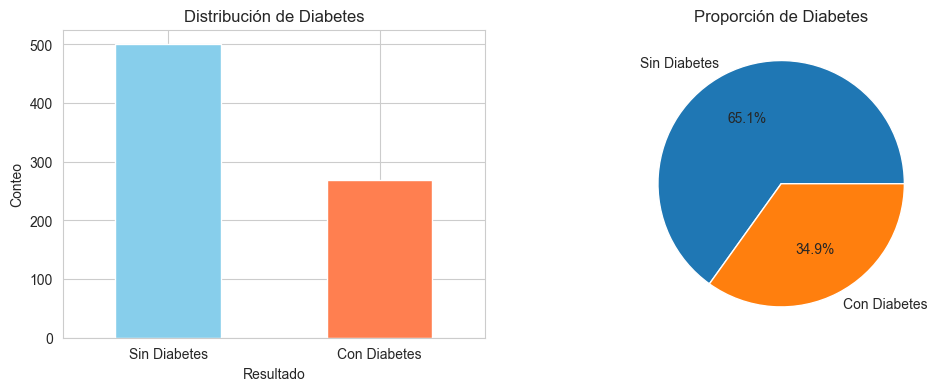

In [31]:
# Para clasificación binaria
print(f"Variable Objetivo: {target_column}")
print("="*60)

# Distribución de clases (MUY IMPORTANTE)
print("\nDistribución de Clases:")
print(df[target_column].value_counts())
print("\nProporciones de Clases:")
print(df[target_column].value_counts(normalize=True))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Distribución de Diabetes')
axes[0].set_xlabel('Resultado')
axes[0].set_xticklabels(['Sin Diabetes', 'Con Diabetes'], rotation=0)
axes[0].set_ylabel('Conteo')

# Gráfico circular
df['Outcome'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   labels=['Sin Diabetes', 'Con Diabetes'])
axes[1].set_ylabel('')
axes[1].set_title('Proporción de Diabetes')

# Verificar desbalance
class_ratio = df[target_column].value_counts(normalize=True)
print(f"\nRatio de Desbalance: {class_ratio.min():.2%} / {class_ratio.max():.2%}")
if class_ratio.min() < 0.3:
    print("Desbalance de clases detectado - considerar técnicas de balanceo")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Consideración para usar Técnicas de Balanceo
Como el ratio de desbalance es 35/65, consideraré usar técnicas de balanceo para mejorar el rendimiento del modelo de Árbol de Decisión. Evaluaré el rendimiento del modelo con y sin técnicas de balanceo para determinar si es necesario en este caso.

Puedo usar técnicas como:
- Usar pesos de clase en el modelo de Árbol de Decisión para dar más importancia a la clase minoritaria
- Sobremuestreo, Submuestreo o SMOTE. Como el ratio de desbalance no es alto, no voy a usar esta técnica
- Elegir mejores métricas: En datasets desbalanceados, la precisión puede ser engañosa. En su lugar, me enfocaré en métricas como precision, recall, F1-score y el área bajo la curva ROC (AUC-ROC)
- Ajustar el umbral de decisión: En lugar de usar el umbral predeterminado de 0.5 para clasificar muestras, puedo ajustar el umbral para optimizar precision o recall
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Tipos de Datos
Todos los datos son numéricos, no necesito codificar ninguna variable categórica. Puedo usar los datos tal como están para el modelo de Árbol de Decisión.
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Análisis de Correlación

El análisis de correlación para árboles de decisión no es necesario, pero podemos reducir el número de variables y mejorar el rendimiento

</div>

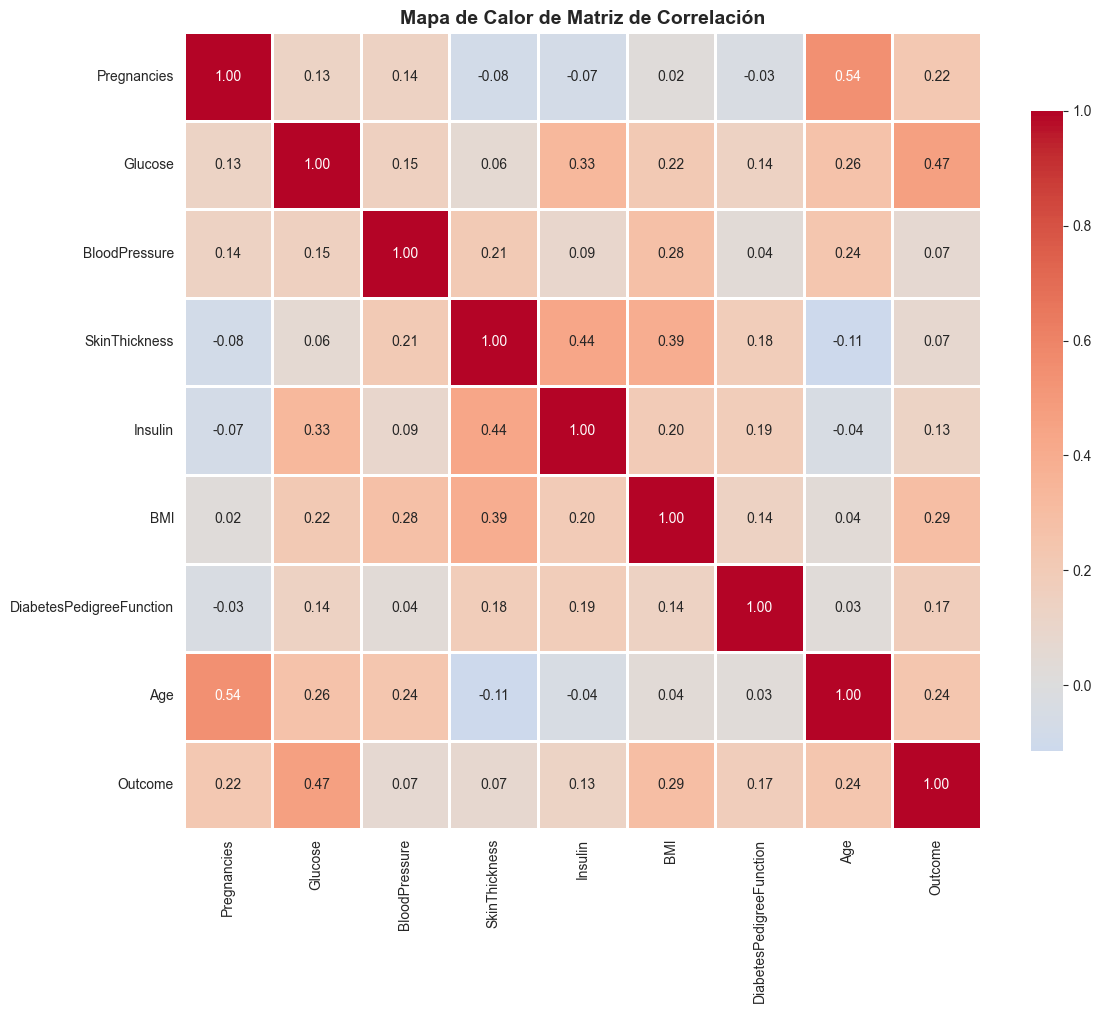


Identificar correlaciones fuertes (|r| > 0.7)


In [32]:
# Visualizar matriz de correlación con mapa de calor
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Mapa de Calor de Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n" + "="*70)
print("Identificar correlaciones fuertes (|r| > 0.7)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")


Correlaciones de Características con Variable Objetivo: Outcome
• Glucose              | r =  0.467
• BMI                  | r =  0.293
• Age                  | r =  0.238
• Pregnancies          | r =  0.222
• DiabetesPedigreeFunction | r =  0.174
• Insulin              | r =  0.131
• SkinThickness        | r =  0.075
• BloodPressure        | r =  0.065


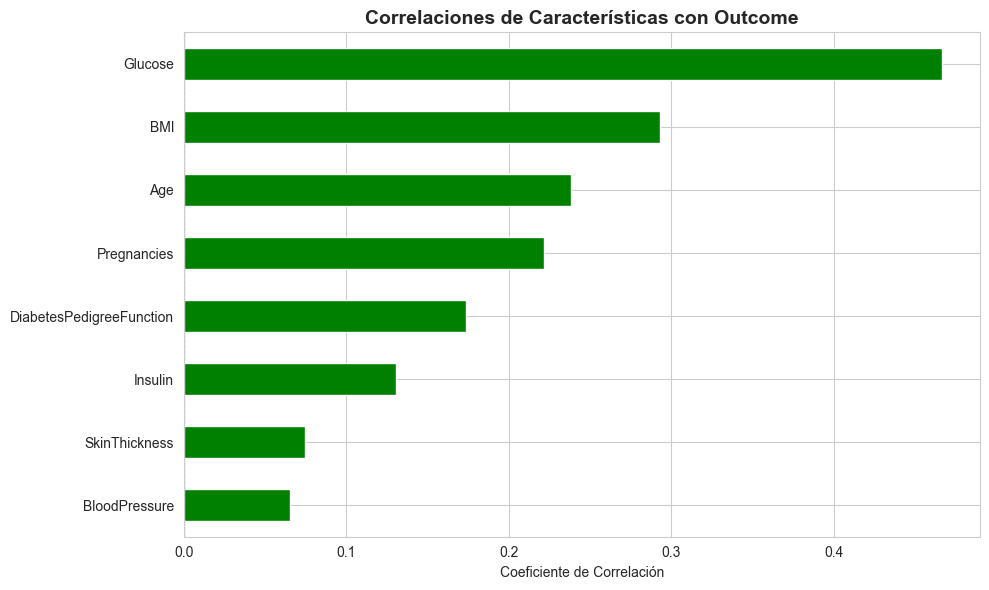

In [33]:
# Correlaciones de características con variable objetivo
target_correlations = correlation_matrix[target_column].drop(target_column)

# Ordenar por valor absoluto (correlaciones más fuertes primero)
target_correlations_sorted = target_correlations.reindex(target_correlations.abs().sort_values(ascending=True).index)

print("\n" + "="*70)
print(f"Correlaciones de Características con Variable Objetivo: {target_column}")
print("="*70)
for feature, corr_value in target_correlations.abs().sort_values(ascending=False).items():
    actual_corr = target_correlations[feature]
    print(f"• {feature:20} | r = {actual_corr:>6.3f}")

# Gráfico de barras de correlaciones con objetivo (más alto arriba)
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_correlations_sorted.values]
target_correlations_sorted.plot(kind='barh', color=colors)
plt.title(f'Correlaciones de Características con {target_column}', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Distribuciones de Características

</div>

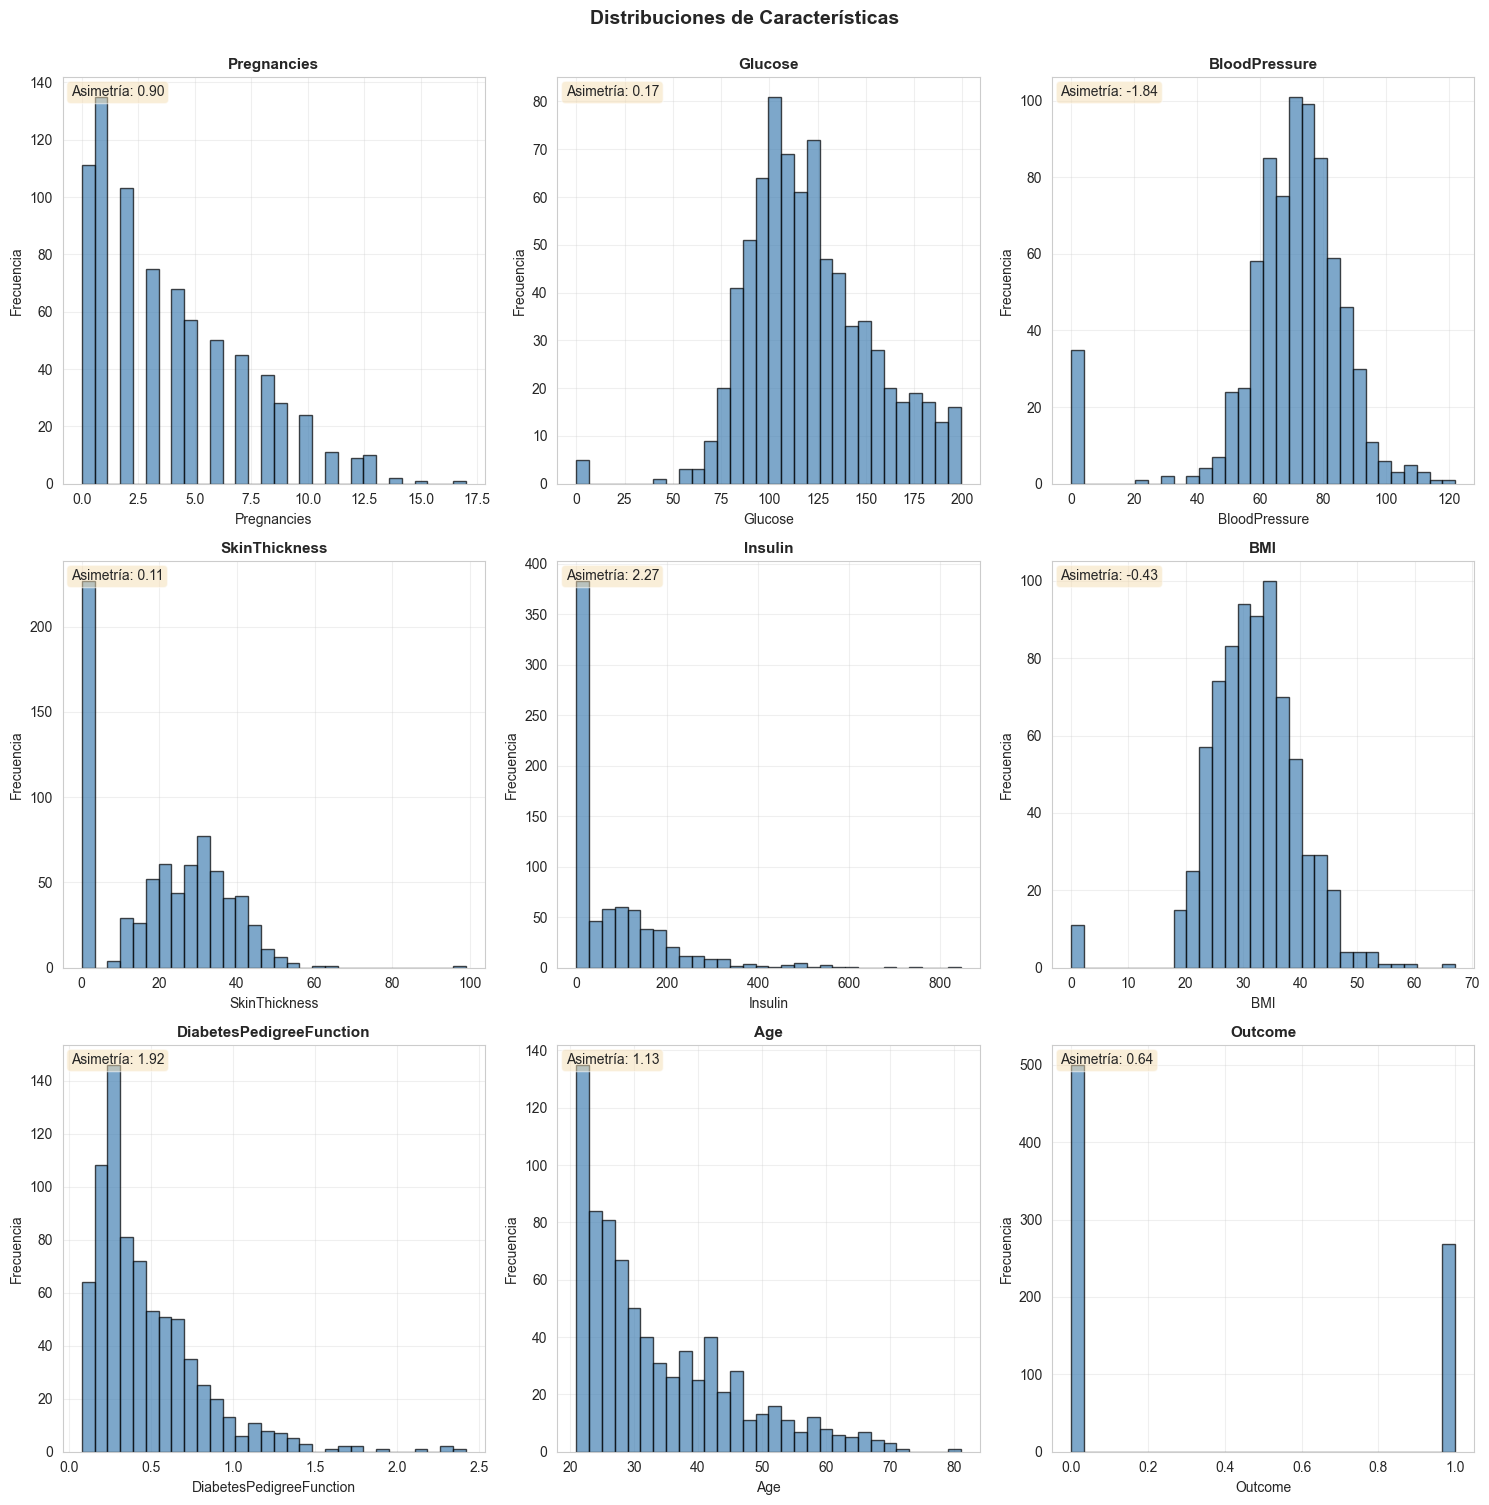

In [34]:
# Histograma para todas las características numéricas
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)
    
    # Agregar información de asimetría
    skewness = df[col].skew()
    axes[idx].text(0.02, 0.98, f'Asimetría: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Ocultar subgráficos vacíos
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribuciones de Características', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Insulina y Grosor de Piel tienen una alta concentración de ceros o valores bajos
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Relaciones Característica vs Objetivo
Diagramas de caja comparando distribuciones de características entre pacientes diabéticos y no diabéticos. Esto ayuda a identificar qué características muestran clara separación entre clases.
</div>

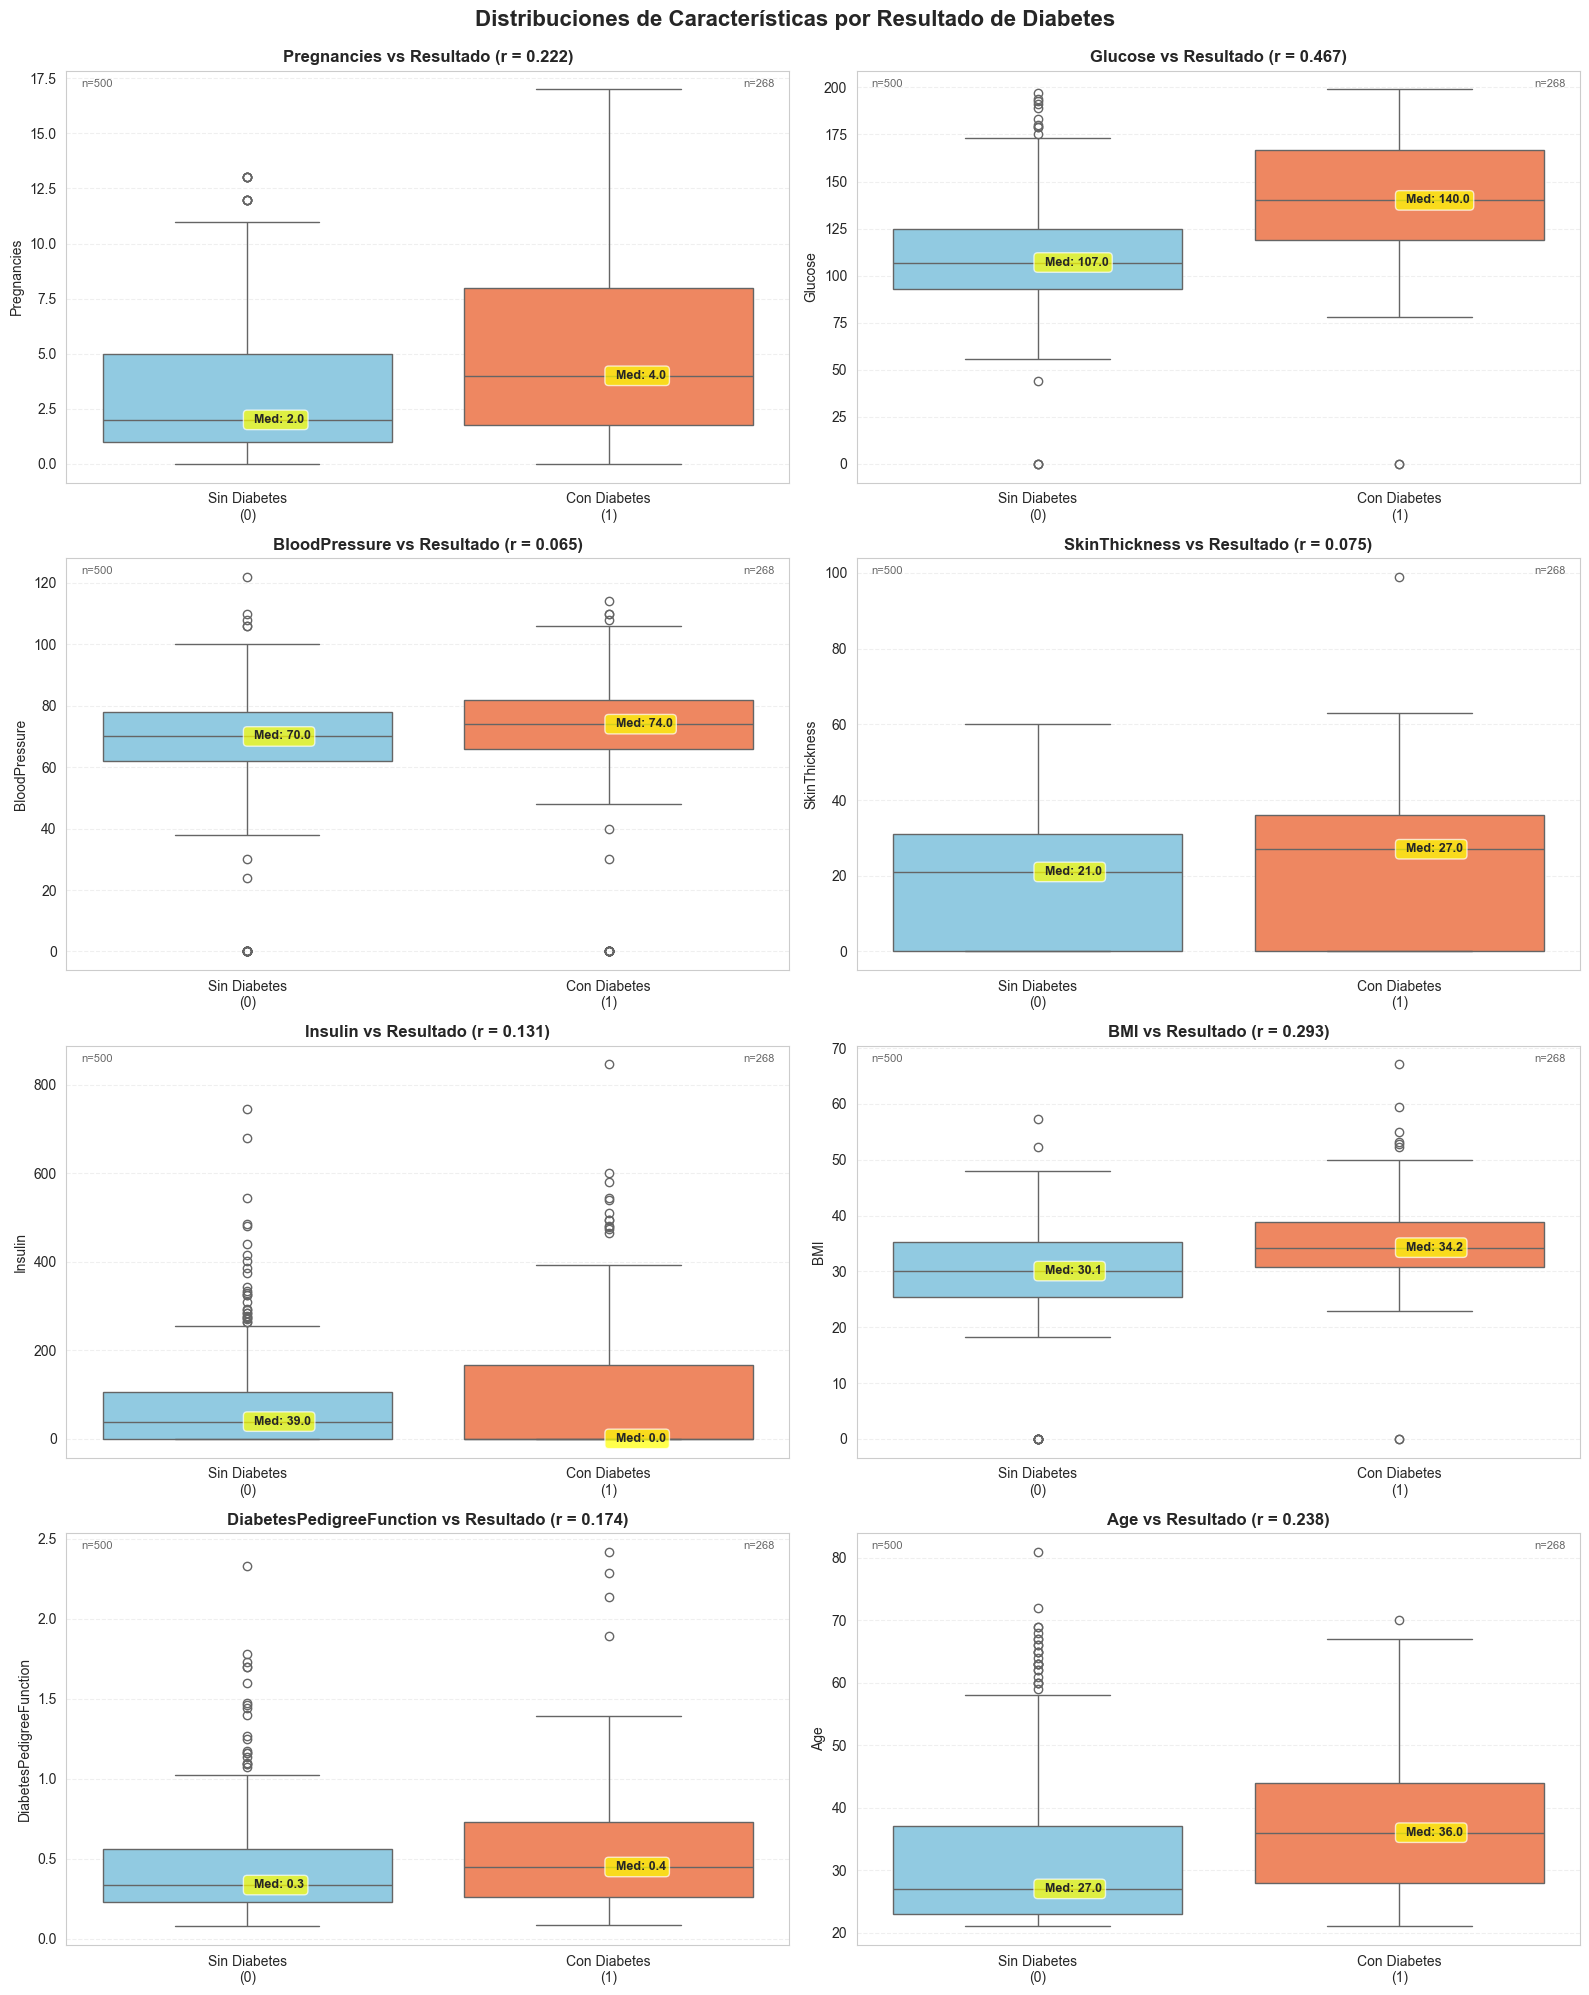

In [35]:
# Boxplots: Características vs Objetivo (comparando distribuciones por estado de diabetes)
features_to_plot = [f for f in numeric_features if f != target_column]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# Definir colores para cada resultado
colors = ['skyblue', 'coral']  # 0: Sin Diabetes (azul), 1: Con Diabetes (coral)

# Calcular tamaños de muestra una vez
n_no_diabetes = (df['Outcome'] == 0).sum()
n_has_diabetes = (df['Outcome'] == 1).sum()

for i, col in enumerate(features_to_plot):
    # Crear boxplot con colores personalizados
    bp = sns.boxplot(data=df, x="Outcome", y=col, ax=axes[i], palette=colors, saturation=0.8)
    
    # Mejorar título con coeficiente de correlación
    corr = df[col].corr(df[target_column])
    axes[i].set_title(f'{col} vs Resultado (r = {corr:.3f})', fontsize=12, fontweight='bold')
    
    # Mejores etiquetas de ejes
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Sin Diabetes\n(0)', 'Con Diabetes\n(1)'])
    axes[i].set_ylabel(col, fontsize=10)
    
    # Agregar cuadrícula para facilitar lectura
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Agregar tamaños de muestra
    axes[i].text(0.02, 0.98, f'n={n_no_diabetes}', transform=axes[i].transAxes,
                 va='top', ha='left', fontsize=8, alpha=0.7)
    axes[i].text(0.98, 0.98, f'n={n_has_diabetes}', transform=axes[i].transAxes,
                 va='top', ha='right', fontsize=8, alpha=0.7)
    
    # Calcular y mostrar valores de mediana para cada grupo
    medians = df.groupby('Outcome')[col].median()
    for j, (outcome, median_val) in enumerate(medians.items()):
        axes[i].text(j, median_val, f'  Med: {median_val:.1f}', 
                     ha='left', va='center', fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.suptitle('Distribuciones de Características por Resultado de Diabetes', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Pairplot (Resumen de Relaciones)
Visualizar todas las relaciones por pares a la vez.
</div>

Creando pairplot para: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


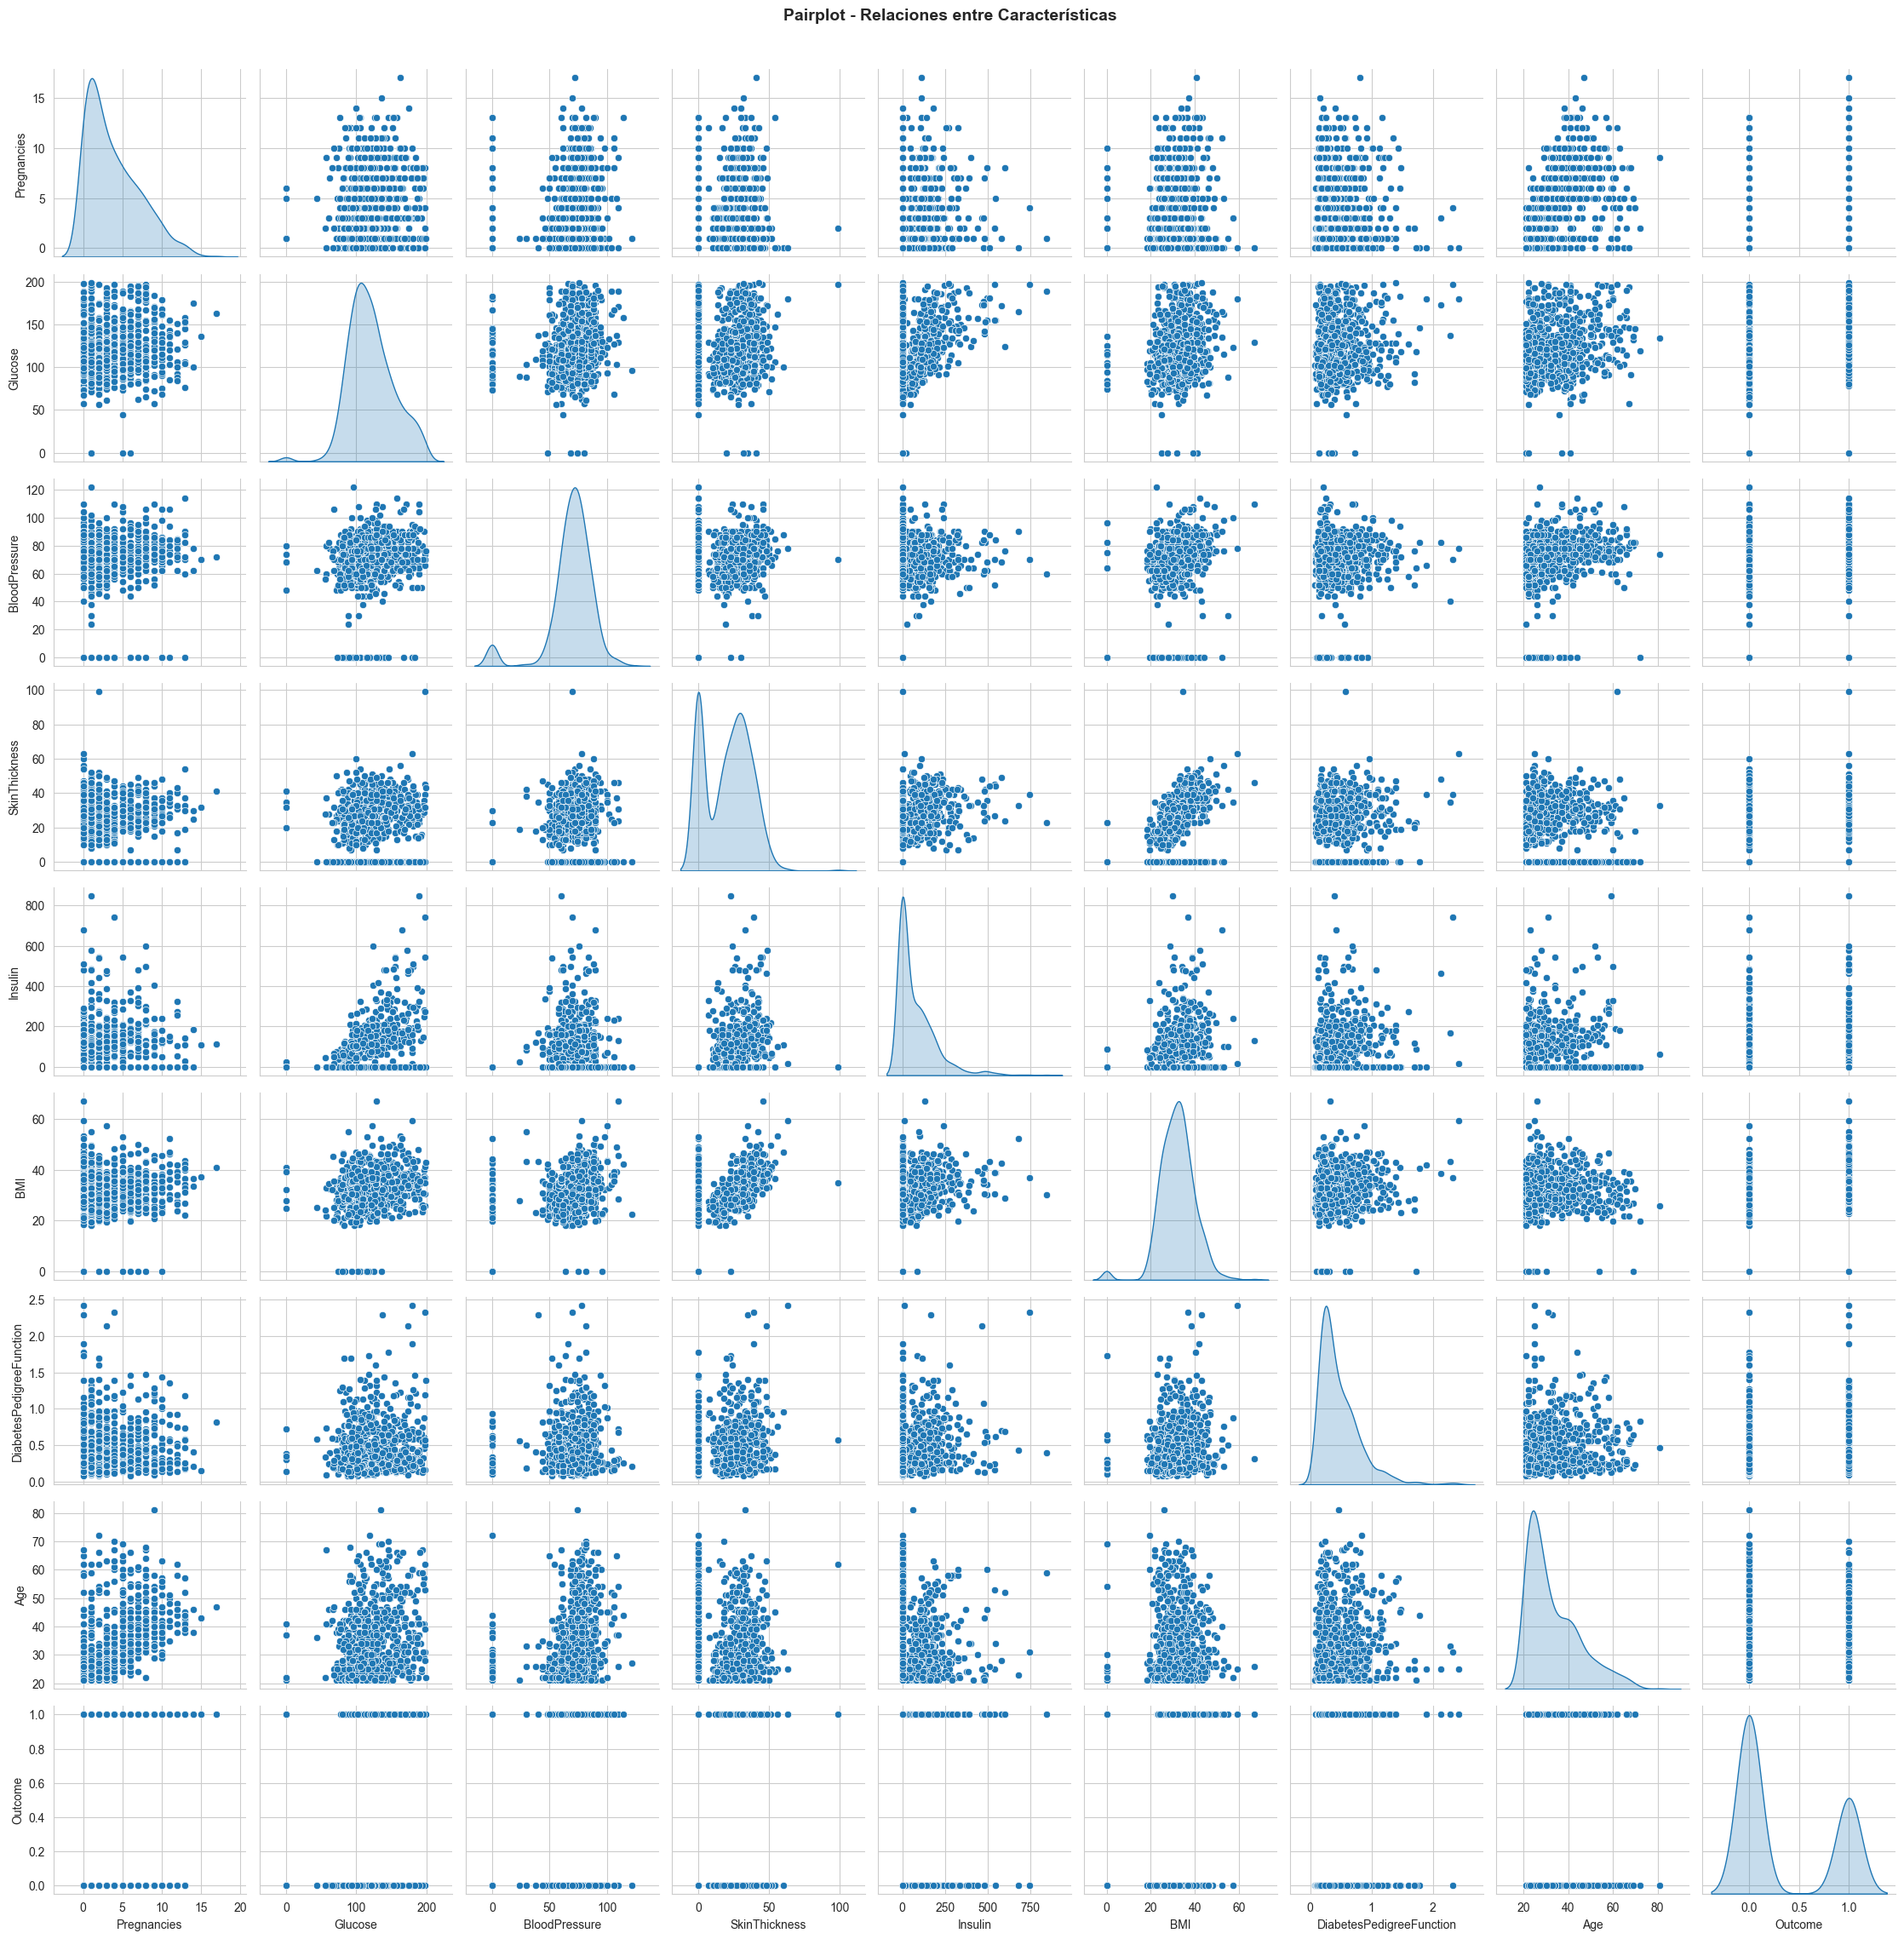

In [36]:
# Pairplot para características numéricas

print(f"Creando pairplot para: {numeric_features}")
sns.pairplot(df[numeric_features], diag_kind='kde', corner=False)
plt.suptitle('Pairplot - Relaciones entre Características', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Este pairplot revela varios insights importantes sobre los datos:

* **Presión Arterial**: Relativamente normal con pico cerca de 0 - ¡Valores cero = datos faltantes!
* **Grosor de Piel**: Pico masivo en 0, luego dispersión - ¡Muchos ceros = datos faltantes!
* **Insulina**: ENORME pico en 0, cola larga a la derecha - ¡Muchos ceros = datos faltantes!

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Preprocesamiento de Datos - Manejar Ceros

* Cambiar ceros a NaN
* Cambiar NaN a Mediana
</div>

In [37]:
# 1. Manejar datos faltantes (ceros)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Calcular conteos de ceros para todas las columnas
zero_counts = {}
for col in cols_with_zeros:
    zero_counts[col] = (df[col] == 0).sum()

# Ordenar por número de ceros (descendente - más ceros primero)
sorted_zeros = sorted(zero_counts.items(), key=lambda x: x[1], reverse=True)

# Imprimir resultados ordenados de mayor a menor
print("="*70)
print("ANÁLISIS DE VALORES CERO (Ordenado por frecuencia)")
print("="*70)
for col, zero_count in sorted_zeros:
    percentage = zero_count/len(df)*100
    print(f"{col:20} | {zero_count:3} ceros ({percentage:5.1f}%)")

ANÁLISIS DE VALORES CERO (Ordenado por frecuencia)
Insulin              | 374 ceros ( 48.7%)
SkinThickness        | 227 ceros ( 29.6%)
BloodPressure        |  35 ceros (  4.6%)
BMI                  |  11 ceros (  1.4%)
Glucose              |   5 ceros (  0.7%)


In [38]:
# Crear una copia del dataset original
df_processed = df.copy()

print("="*70)
print("PIPELINE DE PREPROCESAMIENTO DE DATOS")
print("="*70)

# Paso 1: Identificar columnas con valores cero que representan datos faltantes
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nPaso 1: Verificando valores cero (datos faltantes)")
print("-"*70)
for col, zero_count in sorted_zeros:
    percentage = zero_count/len(df)*100
    print(f"{col:20} | {zero_count:3} ceros ({percentage:5.1f}%)")

# Paso 2: Reemplazar ceros con NaN
print("\nPaso 2: Reemplazando ceros con NaN")
print("-"*70)
for col in cols_to_impute:
    df_processed[col] = df_processed[col].replace(0, np.nan)
    nan_count = df_processed[col].isnull().sum()
    print(f"   {col:20} {nan_count:4} valores NaN")

print(f"\n✓ Total de filas con algún valor faltante: {df_processed.isnull().any(axis=1).sum()}")
print(f"✓ Forma del dataset: {df_processed.shape}")

PIPELINE DE PREPROCESAMIENTO DE DATOS

Paso 1: Verificando valores cero (datos faltantes)
----------------------------------------------------------------------
Insulin              | 374 ceros ( 48.7%)
SkinThickness        | 227 ceros ( 29.6%)
BloodPressure        |  35 ceros (  4.6%)
BMI                  |  11 ceros (  1.4%)
Glucose              |   5 ceros (  0.7%)

Paso 2: Reemplazando ceros con NaN
----------------------------------------------------------------------
   Glucose                 5 valores NaN
   BloodPressure          35 valores NaN
   SkinThickness         227 valores NaN
   Insulin               374 valores NaN
   BMI                    11 valores NaN

✓ Total de filas con algún valor faltante: 376
✓ Forma del dataset: (768, 9)


In [39]:
# Imputar valores faltantes con la mediana
print("\n" + "="*70)
print("ESTRATEGIA DE IMPUTACIÓN: MEDIANA")
print("="*70)

# Calcular y mostrar medianas ANTES de imputación (excluyendo NaN)
print("\nValores de mediana usados para imputación:")
print("-"*70)
medians = {}
for col in cols_to_impute:
    median_value = df_processed[col].median()
    medians[col] = median_value
    print(f"   {col:20} Mediana = {median_value:.2f}")

# Realizar imputación
imputer = SimpleImputer(strategy='median')
df_processed[cols_to_impute] = imputer.fit_transform(df_processed[cols_to_impute])

# Verificar que no quedan valores faltantes
print("\nVerificación después de imputación:")
print("-"*70)
missing_after = df_processed.isnull().sum().sum()
print(f"   Total de valores faltantes: {missing_after}")
if missing_after == 0:
    print("   ✓ ¡Todos los valores faltantes fueron imputados exitosamente!")
else:
    print(f"   ⚠ Advertencia: {missing_after} valores faltantes aún permanecen")

# Mostrar estadísticas resumen después de preprocesamiento
print("\n📈 Resumen del dataset después del preprocesamiento:")
print("-"*70)
print(f"   Total de filas: {len(df_processed)}")
print(f"   Total de columnas: {len(df_processed.columns)}")
print(f"   Características: {len(df_processed.columns) - 1}")  # Excluyendo objetivo
print(f"   Objetivo: {target_column}")


ESTRATEGIA DE IMPUTACIÓN: MEDIANA

Valores de mediana usados para imputación:
----------------------------------------------------------------------
   Glucose              Mediana = 117.00
   BloodPressure        Mediana = 72.00
   SkinThickness        Mediana = 29.00
   Insulin              Mediana = 125.00
   BMI                  Mediana = 32.30

Verificación después de imputación:
----------------------------------------------------------------------
   Total de valores faltantes: 0
   ✓ ¡Todos los valores faltantes fueron imputados exitosamente!

📈 Resumen del dataset después del preprocesamiento:
----------------------------------------------------------------------
   Total de filas: 768
   Total de columnas: 9
   Características: 8
   Objetivo: Outcome


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## División Entrenamiento-Prueba

Dividir los datos en conjuntos de entrenamiento y prueba manteniendo la distribución de clases. Usar stratify para mantener 80/20 para la columna objetivo en los datasets de prueba y entrenamiento.

</div>

In [40]:
X = df_processed.drop(columns="Outcome")
y = df_processed["Outcome"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X: (768, 8)
Forma de y: (768,)
Forma de X_train: (614, 8)
Forma de X_test: (154, 8)
Forma de y_train: (614,)
Forma de y_test: (154,)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Guardar el Dataset para usar en los Algoritmos Basados en Árboles

</div>

In [41]:
# Definir directorio de salida
processed_path = "../data/processed/03-diabetes"

# Crear directorio si no existe
os.makedirs(processed_path, exist_ok=True)

print("="*70)
print("GUARDANDO DATOS PROCESADOS")
print("="*70)
print(f"\n📁 Directorio de salida: {processed_path}\n")

# Guardar archivos con seguimiento de progreso
files_saved = []

# 1. Dataset procesado completo
df_processed.to_csv(f"{processed_path}/diabetes_ready.csv", index=False)
files_saved.append(("diabetes_ready.csv", df_processed.shape))
print(f"✓ diabetes_ready.csv       | {df_processed.shape[0]:3} filas × {df_processed.shape[1]} cols")

# 2. Características de entrenamiento
X_train.to_csv(f"{processed_path}/X_train.csv", index=False)
files_saved.append(("X_train.csv", X_train.shape))
print(f"✓ X_train.csv              | {X_train.shape[0]:3} filas × {X_train.shape[1]} cols")

# 3. Características de prueba
X_test.to_csv(f"{processed_path}/X_test.csv", index=False)
files_saved.append(("X_test.csv", X_test.shape))
print(f"✓ X_test.csv               | {X_test.shape[0]:3} filas × {X_test.shape[1]} cols")

# 4. Objetivo de entrenamiento
y_train.to_frame(name="Outcome").to_csv(f"{processed_path}/y_train.csv", index=False)
files_saved.append(("y_train.csv", (len(y_train), 1)))
print(f"✓ y_train.csv              | {len(y_train):3} filas × 1 col")

# 5. Objetivo de prueba
y_test.to_frame(name="Outcome").to_csv(f"{processed_path}/y_test.csv", index=False)
files_saved.append(("y_test.csv", (len(y_test), 1)))
print(f"✓ y_test.csv               | {len(y_test):3} filas × 1 col")

print("\n" + "="*70)
print(f"✅ ÉXITO: {len(files_saved)} archivos guardados en {processed_path}")
print("="*70)

GUARDANDO DATOS PROCESADOS

📁 Directorio de salida: ../data/processed/03-diabetes

✓ diabetes_ready.csv       | 768 filas × 9 cols
✓ X_train.csv              | 614 filas × 8 cols
✓ X_test.csv               | 154 filas × 8 cols
✓ y_train.csv              | 614 filas × 1 col
✓ y_test.csv               | 154 filas × 1 col

✅ ÉXITO: 5 archivos guardados en ../data/processed/03-diabetes
